---
title: "Line Graphs"
subtitle: "DS 2023 | Communicating with Data"
---

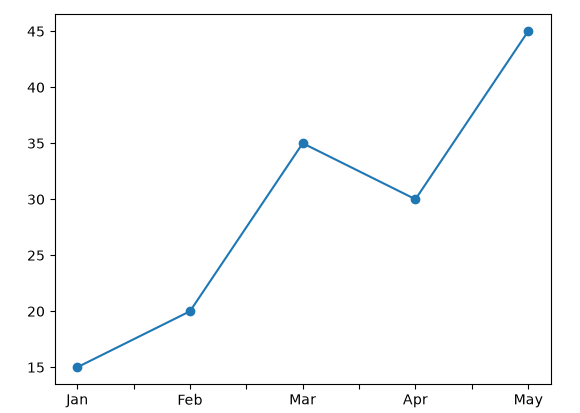

## Overview

Bar charts show measurement variables associated with the domains of group variables.

Pie charts show measurement variables associated with the domains of group variables where the domain values are exhaustive, exclusive, and relatively few.

Line charts allow us to visualize measurement variables where the x axis consists of a group or measurement variable whose domain is sequential, e.g. a calendar date.

## Use Cases

- **Show trends where x axis represents time**, for example monthly revenue over a fiscal year, daily average temperature, a patient's blood pressure across visits, website traffic per week, or population by decade.

- **Compare trends**, for example sales of three product lines side by side, unemployment rates in several countries, control vs. treatment groups in a trial, or actual vs. forecast budget.

- **Plot classical mathematical functions, e.g. linear functions like $y = mx + b$**, for example the parabola $y = x^2$, the sine wave $y = \sin x$, exponential decay $y = e^{-kt}$, or the hyperbola $y = 1/x$.

- **Show process types**, for example the heating curve of water through its phase changes, a capacitor charging and discharging, or a stress–strain curve for a material under load.

## A simple example

Let's look at a simple example.

Below, we visualize a small data set showing sales number over a series of years.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    'year': [2021, 2022, 2023, 2024, 2025, 2026],
    'sales': [100, 120, 170, 160, 210, 240]
}
df1 = pd.DataFrame(data)
df1

,year,sales
0,2021,100
1,2022,120
2,2023,170
3,2024,160
4,2025,210
5,2026,240


To create a line graph in Pandas, you can just call `.plot()` by itself. 

Line graphs are the default plot type.

In the example below, we set `x` to `Year` and `y` to `Sales.` 

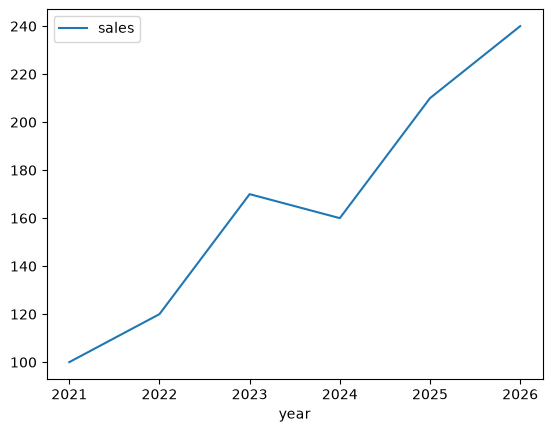

In [3]:
df1.plot(x='year', y='sales')
plt.show()

Of course, we can also call the `.line()` method explicitly.

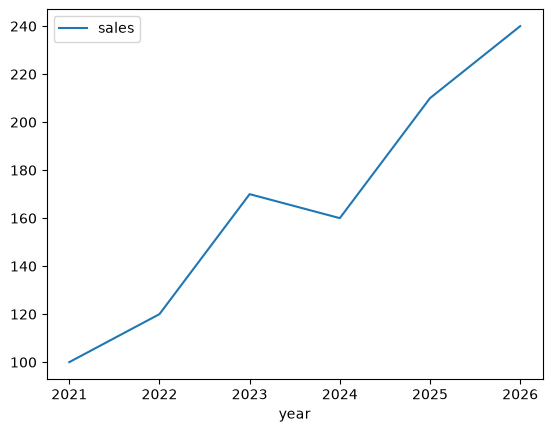

In [4]:
df1.plot.line(x='year', y='sales')
plt.show()

Or we can set the `kind` argument to `line`

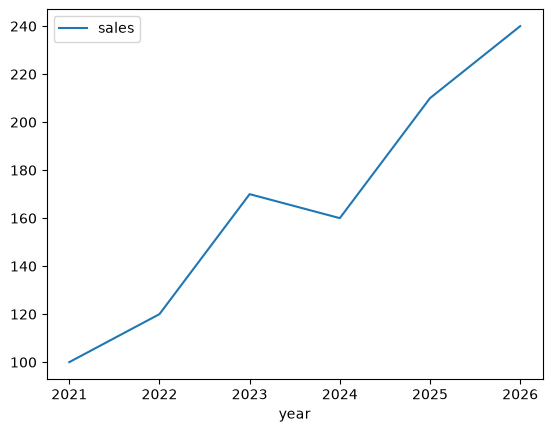

In [5]:
df1.plot(x='year', y='sales', kind='line')
plt.show()

## Another simple example

In this example, we demonstrate how to plot more than one variable in the same figure.

We create data showing number of units sold per month for two products, $A$ and $B$.

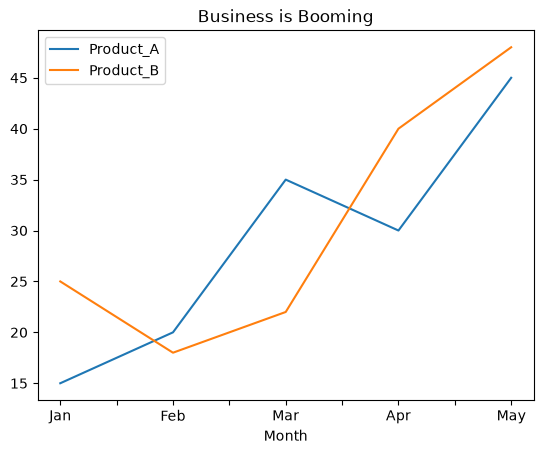

In [6]:
data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May'],
    'Product_A': [15, 20, 35, 30, 45],
    'Product_B': [25, 18, 22, 40, 48]
}
df2 = pd.DataFrame(data)

df2.plot.line(x='Month', y=['Product_A', 'Product_B'], title="Business is Booming")
plt.show()

:::{note}

It makes sense to show multiple lines in the same figure if their associated features have the same domain. 

In the example both lines represent prices of products.

:::

We can show the two lines on separate axes with the `subplots` argument set to `True`.

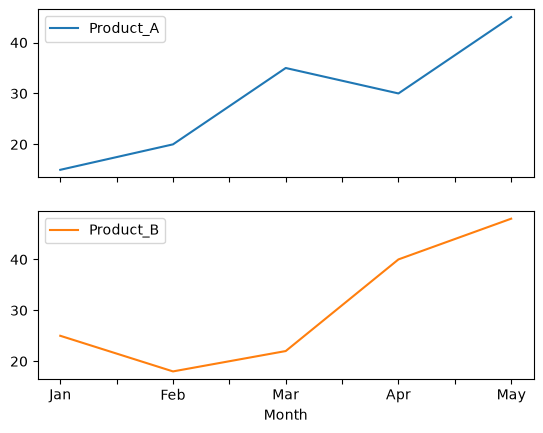

In [7]:
df2.plot.line(x='Month', y=['Product_A', 'Product_B'], subplots=True)
plt.show()

## Using Pandas' indexes

As we saw earlier, Pandas defaults to showing the index of a data frame on the x axis if x is left unspecified.

Here we set the index to `Month`, since the values are uniqure over the observations.

Then, since the remaining non-index features are related, we don't need to specify those, either. Pandas assumes you want to show them all.

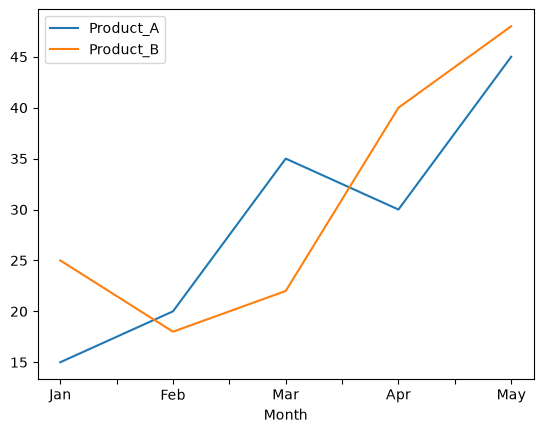

In [8]:
df3 = df2.set_index('Month')
df3.plot()
plt.show()

Here we change the style of plot to show points as well as lines.

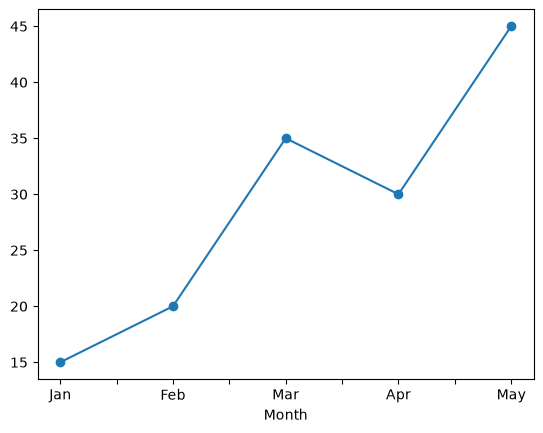

In [9]:
df3.Product_A.plot.line(style = '-o')
plt.show()

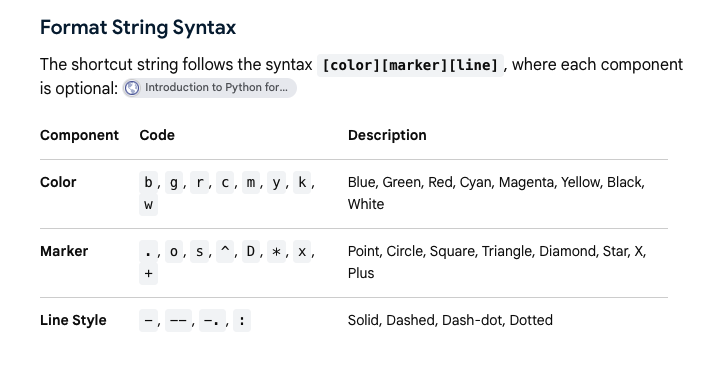

We can set the attributes of multiple lines by passing lists to the arguments.

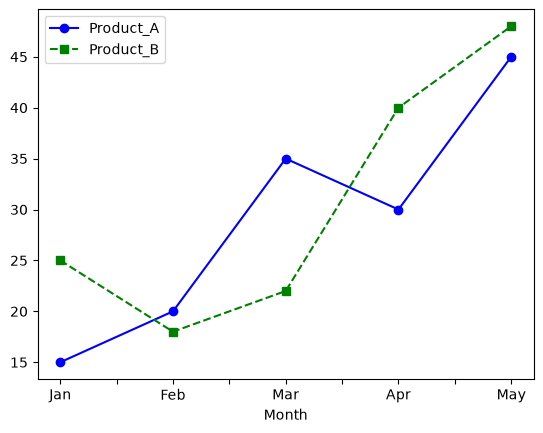

In [10]:
df3.plot.line(style=['o-', 's--'], color=['blue', 'green'])
plt.show()

Note that these data _can_ be visualized with a bar chart. 

However, they are better visualized with a line graph to show the trend of the data over the sequence.

The bar chart is useful here is you want to emphasize differences between $A$ and $B$ per month.

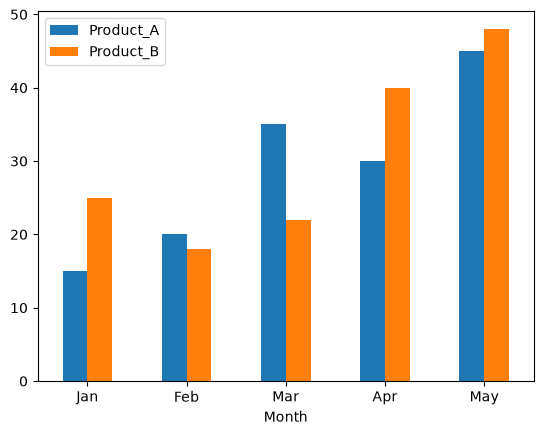

In [11]:
df3.plot.bar(rot=0)
plt.show()

:::{note}

Line graphs and bar charts differ on how they represent domains on the x and y axis.

In contrast to a line graph, in a bar chart:

- The years on the x axis are treated as categories.

- The y axis is not clipped but begins with $0$. As a rule, [bar charts must have a zero baseline](https://www.storytellingwithdata.com/blog/2012/09/bar-charts-must-have-zero-baseline).

:::

## A better example

Let's look at the `mpg` dataset provided by Seaborn.

Let's use these data to see how cars in different coutries have changed over the years 

In [12]:
mpg = sns.load_dataset('mpg')
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


To compare measurements over `year` and `origin`, let's create a wide table with hierarchical columns.

In [13]:
mpg_measures = ['horsepower','mpg','acceleration','weight']

In [14]:
mpg_wide = mpg.pivot_table(index='model_year', columns='origin', values=mpg_measures, aggfunc='mean')
mpg_wide

acceleration                       horsepower             \
origin           europe      japan        usa     europe      japan   
model_year                                                            
70            16.500000  14.750000  11.977273  86.200000  91.500000   
71            16.750000  16.375000  14.575000  74.000000  79.250000   
72            18.700000  15.400000  14.055556  79.600000  93.800000   
73            16.428571  15.625000  13.620690  81.857143  98.500000   
74            15.333333  17.666667  15.966667  74.166667  72.500000   
75            15.083333  16.000000  16.350000  89.500000  80.250000   
76            16.050000  16.575000  15.786364  87.625000  76.500000   
77            15.000000  16.316667  15.238889  81.000000  81.166667   
78            16.233333  16.200000  15.545455  99.166667  79.250000   
79            18.400000  17.200000  15.243478  72.000000  65.000000   
80            18.366667  16.015385  16.800000  66.750000  78.846154   
81            17.500000  16.183333  16.053846  76.666667  78.333333   
82            19.950000  15.833333  16.670000  63.000000  74.000000   

                              mpg                             weight  \
origin             usa     europe      japan        usa       europe   
model_year                                                             
70          166.954545  25.200000  25.500000  15.272727  2309.200000   
71          119.842105  28.750000  29.500000  18.100000  2024.000000   
72          138.777778  22.000000  24.200000  16.277778  2573.200000   
73          146.620690  24.000000  20.000000  15.034483  2335.714286   
74          112.142857  27.000000  29.333333  18.333333  2139.333333   
75          108.700000  24.500000  27.500000  17.550000  2571.166667   
76          110.500000  24.250000  28.000000  19.431818  2611.000000   
77          118.388889  29.250000  27.416667  20.722222  2138.750000   
78          107.272727  24.950000  29.687500  21.772727  2691.666667   
79          109.434783  30.450000  32.950000  23.478261  2693.750000   
80           88.833333  37.288889  35.400000  25.914286  2348.000000   
81           84.538462  31.575000  32.958333  27.530769  2725.000000   
82           86.947368  40.000000  34.888889  29.450000  2055.000000   

                                      
origin            japan          usa  
model_year                            
70          2251.000000  3716.500000  
71          1936.000000  3401.600000  
72          2300.400000  3682.666667  
73          2397.250000  3821.448276  
74          2053.000000  3503.333333  
75          2303.250000  3533.200000  
76          2217.500000  3405.409091  
77          2295.833333  3422.000000  
78          2221.250000  3141.136364  
79          1997.500000  3210.217391  
80          2290.307692  2822.428571  
81          2269.166667  2695.000000  
82          2132.777778  2637.750000

Note the structure of this table. 

The series from the index will define the x-axis and the series associated with the columns will define separate y-axis values. 

The result will be three plots for eacg aggregated feature.

## Comparisons

Now, with the table structured this way, we can easily iterate through the measurement variables and generate graphs that compare `origin` values within each aggregated measure.

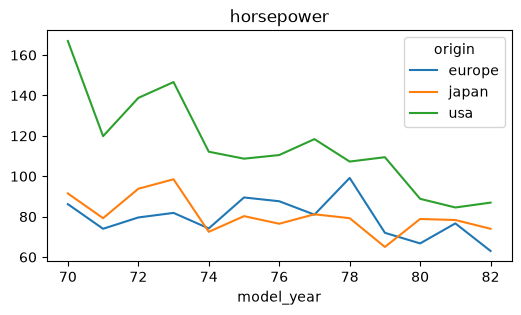

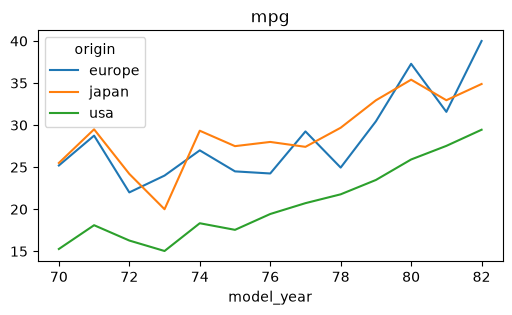

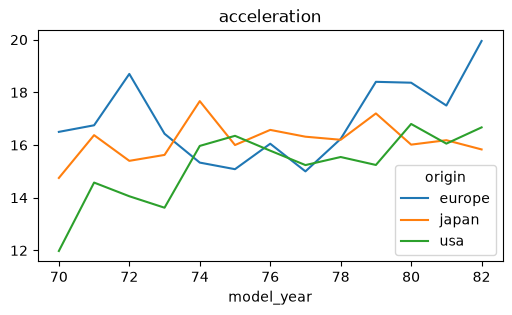

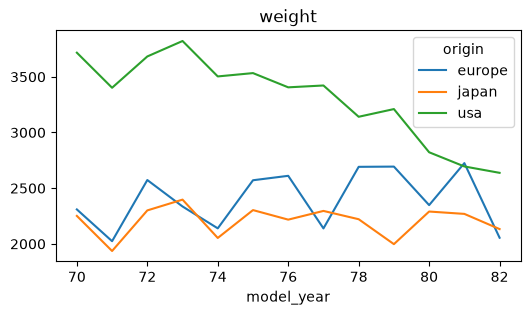

In [15]:
for measure_col in mpg_measures:
    mpg_wide[measure_col].plot(figsize=(6,3), title=measure_col)
plt.show()

Comparing these plots, we can see a couple of things.

First, as `mpg` went up during the 1970s, `horsepower` went down.

Second, the United States has favored `horsepower` over `mpg` in comparison to Europe and Japan.

What else can you see?

## A more complex example

Let's look another example the contains multiple measurements that can be plotted against time.

John Arbuthnot's (1710) data set describes male and female births for London from 1629&ndash;1710.

> [!note] These time series data were used to carry out the first known significance test. 

During every one of the $81$ years, there were more male christenings (i.e. births) than female christenings. 

As Arbuthnot asked, is this difference due to chance or did it mean the birth ratio was actually not $1:1$?

In [30]:
# data_url = "https://vincentarelbundock.github.io/Rdatasets/csv/HistData/Arbuthnot.csv"
data_url = "https://virginia.box.com/shared/static/tpree5hiavq5et794htm7208vc0anulm.csv"
dfx = pd.read_csv(data_url)
dfx.info()
dfx = dfx.set_index('Year')
dfx = dfx.drop("rownames", axis=1)
dfx.head()

<class 'pandas.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   rownames   82 non-null     int64  
 1   Year       82 non-null     int64  
 2   Males      82 non-null     int64  
 3   Females    82 non-null     int64  
 4   Plague     82 non-null     int64  
 5   Mortality  82 non-null     int64  
 6   Ratio      82 non-null     float64
 7   Total      82 non-null     float64
dtypes: float64(2), int64(6)
memory usage: 5.3 KB


,Males,Females,Plague,Mortality,Ratio,Total
Year,,,,,,
1629,5218,4683,0,8771,1.114243,9.901
1630,4858,4457,1317,10554,1.089971,9.315
1631,4422,4102,274,8562,1.078011,8.524
1632,4994,4590,8,9535,1.088017,9.584
1633,5158,4839,0,8393,1.065923,9.997


Here are what the column names stand for:

- Year:    The year, ranging from 1629 to 1710.
- Males:   Number of male christenings (births).
- Females: Number of female christenings (births).
- Plague:  Number of deaths from the Plague.
- Mortality: Total deaths (all causes combined) for that calendar year.
- Ratio:   Ration of Males to Females.
- Total:  The total number of births scaled in thousands (000s).

Now, let's look at `Total`, the total number of births during this period.

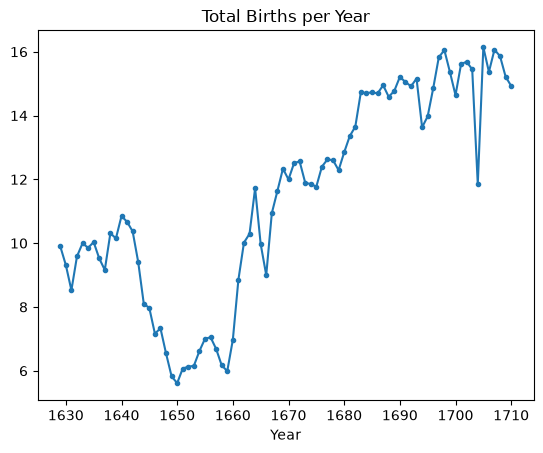

In [31]:
dfx['Total'].plot(style='.-', legend=False, title="Total Births per Year")
plt.show()

For sake of comparison, look at how these same data appear when plotted as a bar chart. What differences do you notice in how the axes are represented?

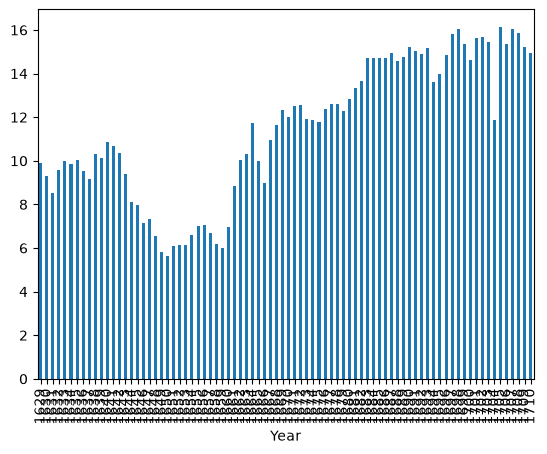

In [36]:
dfx['Total'].plot.bar()
plt.show()

In any case, we can see a big trough between around 1640 and 1665.

Let's look at all the variables together to see in any variables shed light on this.

To do this, we can use the `subplots` argument.

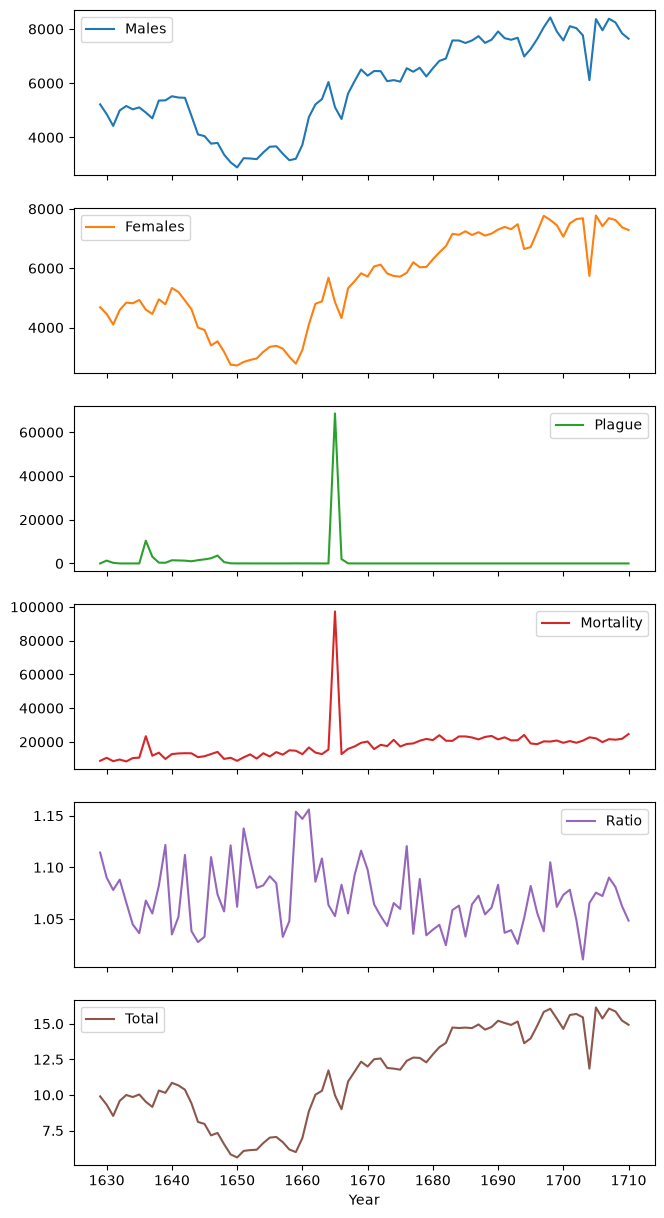

In [32]:
dfx.plot(subplots=True, figsize=(7.5,15))
plt.show()

It appears there are two general kinds of trend here &mdash; those that show births, and those that show deaths. It would be nice to compare them.

Let's compare `Total` to `Mortality`.

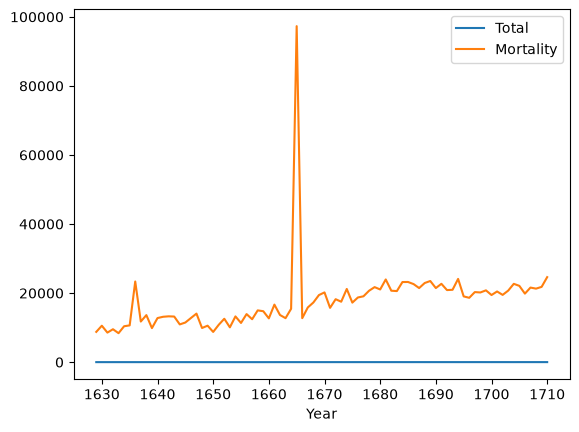

In [19]:
dfx[['Total','Mortality']].plot()
plt.show()

This turns out to be not very useful.

The domains of the two variables are so different that one dwarfs the other.

One quick solution to this problem is to normalize both series by getting their Z-scores.

$$
zscore(x) = (x - \mu) / \sigma
$$


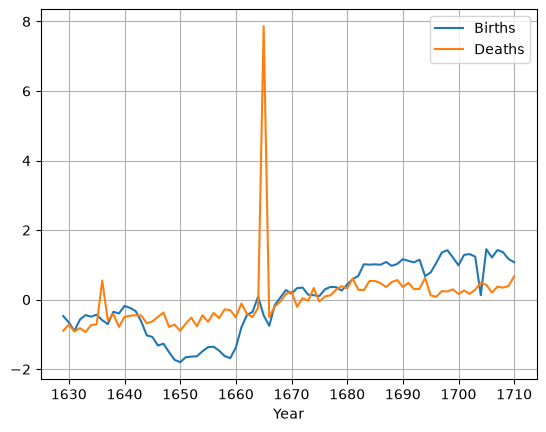

In [37]:
dfx1 = dfx[['Total','Mortality']]
dfx1.columns = ['Births','Deaths']
(
    (dfx1 - dfx1.mean()) / dfx1.std()
).plot()
plt.grid()
plt.show()

But there is a better way, at least from the perspective of visualization.

## Showing two y-axis scales on the same axes

When we compare two related variables come from different domains, it becomes a problem to show them on the same axes. 

Matplotlib provides a function to solve this problem -- `ax.twinx()`. 

This function take the `Axes` object returned by a Pandas plot and creates a new `Axes` object that will be overlaid on the first.

In the result, the left spine represents the first plot while right spine represents the second.

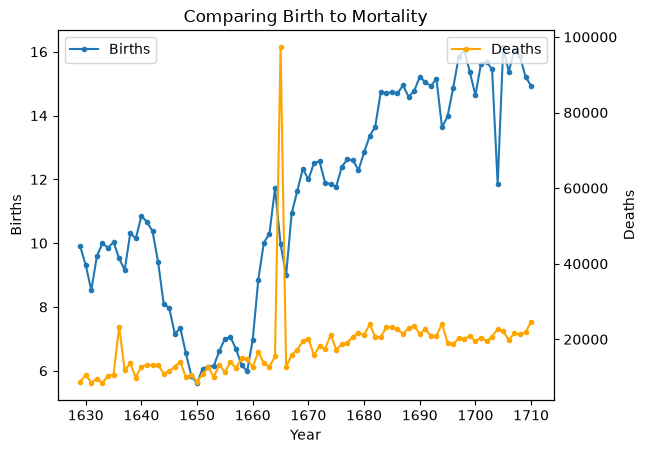

In [42]:
ax = dfx1['Births'].plot(style='.-', legend=True)
ax2 = ax.twinx()
dfx1['Deaths'].plot(ax=ax2, color='orange', style='.-', legend=True)
ax.set_ylabel('Births'), ax2.set_ylabel('Deaths')
plt.title("Comparing Birth to Mortality")
plt.show()

Clearly, there is more work to make this plot production ready, but we are well on our way.

## Plotting mathematical functions

Line charts are also useful for plotting classicial mathematical functions, where $y$ is a function of $x$, i.e. $y = f(x)$.

In [50]:
df = pd.DataFrame()
df['x'] = np.arange(0, 5 * np.pi, 0.1)
df['sin_x'] = np.sin(df.x)
df.head()

,x,sin_x
0,0.0,0.000000
1,0.1,0.099833
2,0.2,0.198669
3,0.3,0.295520
4,0.4,0.389418


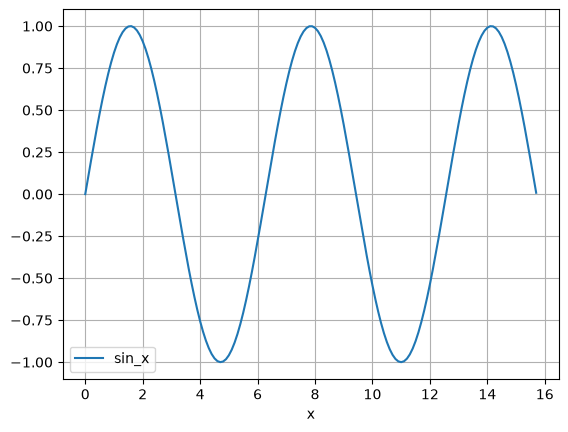

In [51]:
df.plot(x='x', y='sin_x')
plt.grid()
plt.show()

In [52]:
df['cos_x'] = np.cos(df.x)
df.head()

,x,sin_x,cos_x
0,0.0,0.000000,1.000000
1,0.1,0.099833,0.995004
2,0.2,0.198669,0.980067
3,0.3,0.295520,0.955336
4,0.4,0.389418,0.921061


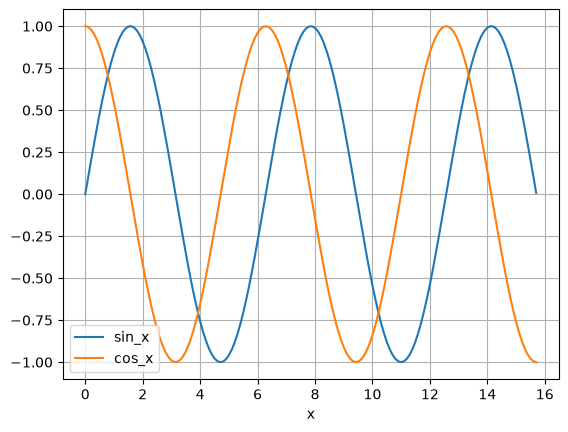

In [53]:
df.plot(x='x', y=['sin_x','cos_x'])
plt.grid()
plt.show()